# A training loop you can reuse

### Eight pieces, each justified by a failure it prevents, and one that did not survive being measured

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | Which pieces of a training loop earn their place and which failure each one prevents, how much accuracy you throw away by keeping the last epoch's weights instead of the best ones, why averaging your metric over batches is wrong, what happened when I pushed the learning rate until gradient clipping was supposed to matter and the divergence never arrived, and one function you can paste into your own project |
| **You should already know** | [The same network in PyTorch](../03-the-same-net-in-pytorch/) · [Optimisers](../05-optimisers/) · [Regularisation](../06-regularisation/) |
| **Dataset** | Fashion-MNIST, cut down so every experiment here is small enough to run on a CPU |
| **Runtime** | A few minutes. The device is chosen at run time and printed by the first code cell, and the timings below came from whichever one it found |
| **Next** | [08-01 Convolution and pooling](../../08-computer-vision/01-convolution-and-pooling/) |

---

## 1. The loop everybody writes first

Here is the training loop from every tutorial, including the earlier chapters of
this book:

```python
for epoch in range(epochs):
    for xb, yb in loader:
        optimiser.zero_grad()
        loss_fn(model(xb), yb).backward()
        optimiser.step()
```

It is correct. It trains. It is also missing everything that turns a script into
a result you can defend, and the gaps are not stylistic:

1. It runs on whatever device the tensors happen to be on.
2. It has no validation set, so nothing can be tuned honestly.
3. If you add a metric to it, you will average it over batches, which is wrong.
4. It stops at a fixed epoch count, not when the model was at its best.
5. It keeps the last epoch's weights, which are usually not the best ones.
6. It uses one learning rate for the whole run.
7. It has no protection against a gradient large enough to destroy the weights.
8. It saves nothing, so a crash near the end costs you the entire run.
9. It is not reproducible, so you cannot tell an improvement from a lucky seed.

Nine gaps, eight pieces. Items four and five close together, because deciding
when to stop and deciding which weights to keep are one function in code and two
separate ideas in your head, and confusing them is the subject of piece five.

This chapter adds those pieces one at a time. Every piece has to justify itself by
a failure it prevents, and where the failure is measurable I measure it rather
than describing it. One of them did not survive being measured, which is section
3's piece seven.

In [1]:
import sys
import pathlib
import copy
import math
import random
import tempfile
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

### Piece one: device handling

One line, written once, at the top. Everything else keys off it.

The failure it prevents is a `RuntimeError` complaining that two tensors are on
different devices, and it is worth understanding rather than fixing by trial and
error. `model.to(device)` moves parameters **in place** and returns the model.
`tensor.to(device)` does **not** move in place; it returns a copy, and forgetting
to assign it is the most common version of this bug:

```python
xb.to(device)          # does nothing you can see
xb = xb.to(device)     # the one that works
```

There is no honest measurement to make here on a machine with one device, so this
piece gets a rule rather than a chart: select the device once, move the model once,
and move every batch at the point of use.

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__} on {device}")
if device == "cuda":
    print(f"gpu: {torch.cuda.get_device_name(0)}")

torch 2.11.0+cu128 on cuda
gpu: NVIDIA RTX A2000 Laptop GPU


### Piece two: a real train / validation split

The test set exists to be measured once, at the end. Anything you use to make a
decision, including when to stop, is a validation set by definition, and if that
decision is made against the test set then the number you report is optimistic by
an amount you cannot estimate.

So the training pool gets cut into three: train, validation, and a test set that
nothing touches until section 5.

In [3]:
from torch.utils.data import DataLoader, TensorDataset

N_TRAIN, N_VAL = 4000, 1000
EPOCHS, BATCH = 20, 128

train_pool = datasets.fashion_mnist(train=True)
test_set = datasets.fashion_mnist(train=False)
CLASSES = ["T-shirt", "trouser", "pullover", "dress", "coat",
           "sandal", "shirt", "sneaker", "bag", "boot"]


def stack(dataset, indices=None):
    """Pull a dataset into two tensors on the device, once."""
    from torch.utils.data import Subset
    if indices is not None:
        dataset = Subset(dataset, indices)
    images, labels = next(iter(DataLoader(dataset, batch_size=len(dataset))))
    return images.to(device), labels.to(device)


order = torch.randperm(len(train_pool), generator=torch.Generator().manual_seed(SEED)).tolist()
X_train, y_train = stack(train_pool, order[:N_TRAIN])
X_val, y_val = stack(train_pool, order[N_TRAIN:N_TRAIN + N_VAL])
X_test, y_test = stack(test_set)

print(f"train      : {len(X_train):,}")
print(f"validation : {len(X_val):,} (drawn from the training pool, never from test)")
print(f"test       : {len(X_test):,} (untouched until section 5)")
print(f"validation batches at batch size {BATCH}: "
      f"{math.ceil(len(X_val) / BATCH)}, last one holds {len(X_val) % BATCH} rows")

train      : 4,000
validation : 1,000 (drawn from the training pool, never from test)
test       : 10,000 (untouched until section 5)
validation batches at batch size 128: 8, last one holds 104 rows


That last line is not decoration. It is the setup for the next piece.

## 2. The three formulas the loop actually needs

### Averaging a metric

You have per-batch numbers and you want the number for the whole set. The
temptation is

$$\bar{a}_{\text{wrong}} = \frac{1}{B}\sum_{b=1}^{B} a_b$$

which treats a batch of eight rows as equal in weight to a batch of a hundred and
twenty-eight. The right one carries the counts:

$$\bar{a} = \frac{\sum_b n_b\, a_b}{\sum_b n_b}$$

The two agree exactly when every batch is the same size, which is why the bug
survives so long: it is invisible until your dataset stops dividing evenly by your
batch size, and then it is still small enough to look like noise.

### Gradient clipping

Compute the total norm over all parameters, and if it exceeds a threshold, rescale
every gradient by the same factor so the direction survives and only the length
changes:

$$g \leftarrow g \cdot \min\!\left(1, \frac{\tau}{\lVert g \rVert_2}\right)$$

Clipping by norm rather than clipping each element separately matters. Element-wise
clipping changes the direction of the step; norm clipping does not.

### Cosine annealing

One schedule worth knowing by its formula, because it has no dials to guess:

$$\eta_t = \eta_{\min} + \tfrac{1}{2}(\eta_{\max}-\eta_{\min})
           \left(1 + \cos\frac{t\pi}{T}\right)$$

It starts at $\eta_{\max}$, ends at $\eta_{\min}$, and spends most of its time in
between rather than at either end.

## 3. The pieces, one at a time

### Piece three: metric accumulation that does not silently average wrong

In [4]:
class Average:
    """A sample-weighted running mean. The weight is the part people forget."""

    def __init__(self):
        self.total, self.count = 0.0, 0

    def add(self, value, n):
        self.total += float(value) * n
        self.count += n

    @property
    def value(self):
        return self.total / max(self.count, 1)


def score_two_ways(model, X, y, batch_size):
    """Return (weighted accuracy, mean-of-batches accuracy) on the same forward passes."""
    model.eval()
    weighted, per_batch = Average(), []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb, yb = X[i:i + batch_size], y[i:i + batch_size]
            batch_accuracy = (model(xb).argmax(1) == yb).float().mean().item()
            weighted.add(batch_accuracy, len(yb))
            per_batch.append(batch_accuracy)
    return weighted.value, float(np.mean(per_batch))


def build_net(widths=(128, 64), n_classes=10, seed=SEED):
    """The one architecture used throughout, re-seeded so runs start identically."""
    torch.manual_seed(seed)
    layers, n_in = [nn.Flatten()], 28 * 28
    for width in widths:
        layers += [nn.Linear(n_in, width), nn.ReLU()]
        n_in = width
    layers.append(nn.Linear(n_in, n_classes))
    return nn.Sequential(*layers).to(device)


# A partly trained model, so the accuracies being averaged are not all identical.
warmup = build_net()
optimiser = torch.optim.SGD(warmup.parameters(), lr=0.1, momentum=0.9)
loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH, shuffle=True,
                    generator=torch.Generator().manual_seed(SEED))
loss_fn = nn.CrossEntropyLoss()
warmup.train()
for _ in range(3):
    for xb, yb in loader:
        optimiser.zero_grad()
        loss_fn(warmup(xb), yb).backward()
        optimiser.step()

print(f"warm-up model trained for 3 epochs, weighted validation accuracy "
      f"{score_two_ways(warmup, X_val, y_val, 1000)[0]:.4f}")

warm-up model trained for 3 epochs, weighted validation accuracy 0.7490


In [5]:
# Two orderings of the same 1,000 rows. Sorted order is not a contrivance: it is
# what you get whenever an evaluation set is grouped by class, which is common.
sorted_rows = torch.argsort(y_val)
X_val_sorted, y_val_sorted = X_val[sorted_rows], y_val[sorted_rows]

BATCH_SIZES = [16, 32, 48, 64, 96, 128, 192, 256, 384, 512, 768]
accumulation = []
for size in BATCH_SIZES:
    right_shuffled, wrong_shuffled = score_two_ways(warmup, X_val, y_val, size)
    right_sorted, wrong_sorted = score_two_ways(warmup, X_val_sorted, y_val_sorted, size)
    accumulation.append({
        "batch size": size,
        "last batch": len(X_val) % size or size,
        "correct": right_shuffled,
        "naive, shuffled": wrong_shuffled,
        "naive, sorted": wrong_sorted,
        "error, shuffled order": abs(wrong_shuffled - right_shuffled),
        "error, sorted by class": abs(wrong_sorted - right_sorted),
    })

accumulation = pd.DataFrame(accumulation)
print(accumulation.drop(columns=["naive, shuffled", "naive, sorted"])
      .round(5).to_string(index=False))

worst_sorted = accumulation["error, sorted by class"].max()
worst_shuffled = accumulation["error, shuffled order"].max()
print(f"\nlargest error from averaging over batches, shuffled : {worst_shuffled:.5f}")
print(f"largest error from averaging over batches, sorted   : {worst_sorted:.5f}")
print(f"the correct answer is the same however you slice it: it varies by "
      f"{accumulation['correct'].max() - accumulation['correct'].min():.2e} "
      f"across every batch size tried")

 batch size  last batch  correct  error, shuffled order  error, sorted by class
         16           8    0.749                0.00098                 0.00100
         32           8    0.749                0.00291                 0.00295
         48          40    0.749                0.00001                 0.00080
         64          40    0.749                0.00002                 0.00237
         96          40    0.749                0.00005                 0.00536
        128         104    0.749                0.00070                 0.00295
        192          40    0.749                0.00013                 0.01333
        256         232    0.749                0.00002                 0.00265
        384         232    0.749                0.00013                 0.01492
        512         488    0.749                0.00012                 0.00012
        768         232    0.749                0.00035                 0.03946

largest error from averaging over batch

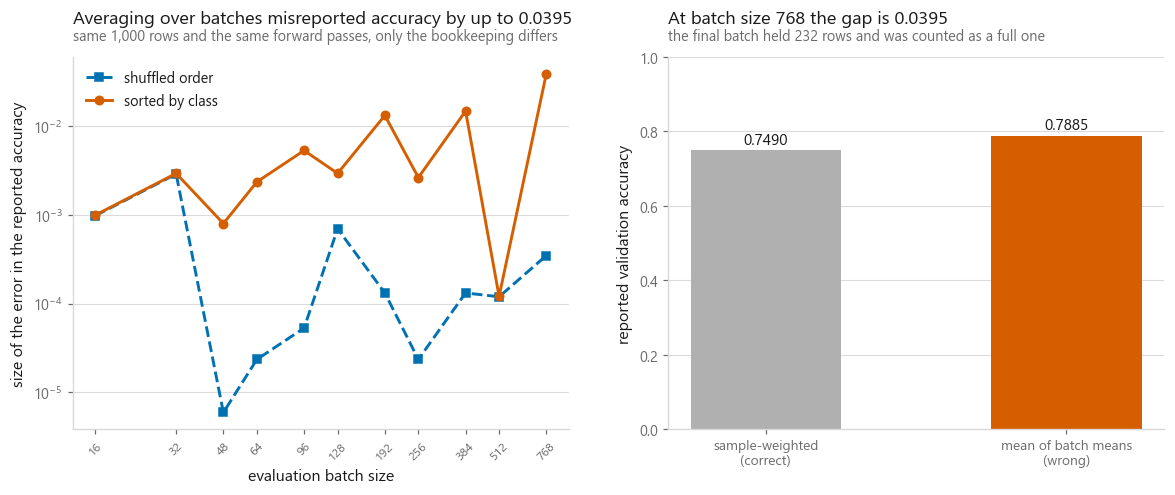

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.4))

for column, colour, marker, dash in [("error, shuffled order", style.PALETTE[0],
                                      style.MARKERS[1], "--"),
                                     ("error, sorted by class", style.HIGHLIGHT,
                                      style.MARKERS[0], "-")]:
    axes[0].plot(accumulation["batch size"], accumulation[column], color=colour,
                 marker=marker, ls=dash, label=column.split(", ")[1])
axes[0].set_yscale("symlog", linthresh=1e-5)
axes[0].set_xscale("log", base=2)
axes[0].set_xticks(BATCH_SIZES, [str(b) for b in BATCH_SIZES], rotation=45, fontsize=8)
axes[0].minorticks_off()
axes[0].set_xlabel("evaluation batch size")
axes[0].set_ylabel("size of the error in the reported accuracy")
axes[0].legend(loc="upper left")
style.title(axes[0], f"Averaging over batches misreported accuracy by up to {worst_sorted:.4f}",
            f"same {len(X_val):,} rows and the same forward passes, only the bookkeeping differs")

peak = accumulation.loc[accumulation["error, sorted by class"].idxmax()]
naive_value = peak["naive, sorted"]
axes[1].bar([0, 1], [peak["correct"], naive_value], width=0.5,
            color=[style.NEUTRAL, style.HIGHLIGHT])
for x, value in enumerate([peak["correct"], naive_value]):
    axes[1].annotate(f"{value:.4f}", xy=(x, value), xytext=(0, 4),
                     textcoords="offset points", ha="center", fontsize=10, color=style.INK)
axes[1].set_xticks([0, 1], ["sample-weighted\n(correct)", "mean of batch means\n(wrong)"],
                   fontsize=9)
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel("reported validation accuracy")
style.title(axes[1], f"At batch size {int(peak['batch size'])} the gap is {peak['error, sorted by class']:.4f}",
            f"the final batch held {int(peak['last batch'])} rows and was counted as a full one")

style.save(fig, FIG / "fig-01-metric-accumulation.png")

On shuffled data the error is small, and small is exactly what makes it dangerous:
it is the size of the difference you are trying to detect between two models. On
grouped data it stops being subtle.

The same bug has a second home. Loss is usually accumulated as
`total += loss.item()` and then divided by `len(loader)`, which is the number of
batches rather than the number of rows. `Average` above fixes both cases with one
class, and it is four lines long.

### Pieces four to seven, in one function

The remaining pieces are entangled, so they arrive together: early stopping needs
the validation loss, best-weight restoration needs early stopping, and both need
somewhere to keep the history. The function below is deliberately still a training
loop rather than a library, so each addition stays visible.

In [7]:
def seed_everything(seed, strict=False):
    """Every generator this loop can touch, set from one number.

    `strict` also forbids non-deterministic kernels. It is off by default because
    some layers have no deterministic implementation and will raise rather than run.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if strict:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        torch.use_deterministic_algorithms(True)


@torch.no_grad()
def evaluate(model, X, y, loss_fn, batch_size=1000):
    """Loss and accuracy, sample-weighted, with eval mode inside so it cannot be forgotten."""
    model.eval()
    loss_meter, accuracy_meter = Average(), Average()
    for i in range(0, len(X), batch_size):
        xb, yb = X[i:i + batch_size], y[i:i + batch_size]
        logits = model(xb)
        loss_meter.add(loss_fn(logits, yb).item(), len(yb))
        accuracy_meter.add((logits.argmax(1) == yb).float().mean().item(), len(yb))
    return loss_meter.value, accuracy_meter.value


def train_once(model, *, epochs=EPOCHS, lr=0.1, batch_size=BATCH, schedule="none",
               clip=None, seed=SEED, track_test=False, collect_norms=False):
    """One run, recording everything the later sections need to compare.

    Returns the history, a deep copy of the weights at the lowest validation loss,
    and the weights at the final epoch, so that section 3 can score both.
    """
    seed_everything(seed)
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimiser = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    # A generator on the loader as well as a global seed, so the shuffling order
    # stays pinned even if something else consumes randomness between epochs.
    loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size,
                        shuffle=True, generator=torch.Generator().manual_seed(seed))

    scheduler = None
    if schedule == "cosine":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=epochs)
    elif schedule == "step":
        scheduler = torch.optim.lr_scheduler.StepLR(optimiser, step_size=7, gamma=0.3)
    elif schedule == "plateau":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimiser, mode="min", factor=0.5, patience=2)

    history = {k: [] for k in ["train_loss", "val_loss", "val_acc", "lr", "test_acc"]}
    norms = []
    best_loss, best_state, best_epoch = math.inf, None, 0

    for epoch in range(1, epochs + 1):
        model.train()
        running = Average()
        for xb, yb in loader:
            optimiser.zero_grad(set_to_none=True)      # set_to_none frees memory and is the default now
            loss = loss_fn(model(xb), yb)
            loss.backward()
            if clip is not None:
                total_norm = nn.utils.clip_grad_norm_(model.parameters(), clip)
            elif collect_norms:
                # A huge threshold clips nothing but still returns the norm.
                total_norm = nn.utils.clip_grad_norm_(model.parameters(), 1e12)
            if collect_norms:
                norms.append(float(total_norm))
            optimiser.step()
            running.add(loss.item(), len(yb))          # weighted, not mean of batch means

        history["lr"].append(optimiser.param_groups[0]["lr"])
        history["train_loss"].append(running.value)

        val_loss, val_accuracy = evaluate(model, X_val, y_val, loss_fn)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_accuracy)
        if track_test:
            history["test_acc"].append(evaluate(model, X_test, y_test, loss_fn)[1])

        if val_loss < best_loss:
            # deepcopy, not a reference: the tensors below keep training otherwise.
            best_loss, best_epoch = val_loss, epoch
            best_state = copy.deepcopy(model.state_dict())

        if scheduler is not None:
            scheduler.step(val_loss) if schedule == "plateau" else scheduler.step()

    return {"history": history, "best_state": best_state, "best_epoch": best_epoch,
            "best_val_loss": best_loss, "last_state": copy.deepcopy(model.state_dict()),
            "optimiser_state": copy.deepcopy(optimiser.state_dict()),
            "grad_norms": norms, "model": model}

### Piece four: seeds, and the size of the noise floor

Before measuring anything else, measure how much the answer moves when nothing
changes but the seed. Any improvement smaller than that spread is not an
improvement.

In [8]:
SEEDS = [0, 1, 2, 3]
runs = {}
started = time.perf_counter()
for s in SEEDS:
    runs[s] = train_once(build_net(seed=s), seed=s)
print(f"{len(SEEDS)} runs in {time.perf_counter() - started:.0f}s\n")

# A short repeat of the first configuration. Five epochs is enough to prove the
# point and cheaper than redoing all twenty.
repeat = train_once(build_net(seed=SEEDS[0]), seed=SEEDS[0], epochs=5)
identical = np.allclose(repeat["history"]["val_loss"],
                        runs[SEEDS[0]]["history"]["val_loss"][:5])
print(f"same seed twice gives the same validation curve: {identical}")

final_val = np.array([runs[s]["history"]["val_acc"][-1] for s in SEEDS])
print(f"final validation accuracy across seeds: "
      f"{final_val.min():.4f} to {final_val.max():.4f}")
print(f"spread (max minus min): {final_val.max() - final_val.min():.4f}")
print(f"standard deviation    : {final_val.std():.4f}")

4 runs in 6s



same seed twice gives the same validation curve: True
final validation accuracy across seeds: 0.7900 to 0.8380
spread (max minus min): 0.0480
standard deviation    : 0.0172


### Piece five: early stopping, and restoring the best weights

Two separate ideas that arrive together and are often confused. **Early stopping**
decides when to stop. **Best-weight restoration** decides which weights you keep
once you have stopped. You can do the first without the second, and if you do, you
have thrown away most of the benefit: you stopped after `patience` epochs of
getting worse, and then kept the weights from the worst of them.

This is measurable on the runs already in memory. Every run recorded the epoch of
lowest validation loss and kept a copy of the weights from that epoch, so the test
set can be shown both versions.

In [9]:
loss_fn = nn.CrossEntropyLoss()
restoration = []
for s in SEEDS:
    run = runs[s]
    scratch_model = build_net(seed=s)

    scratch_model.load_state_dict(run["best_state"])
    at_best = evaluate(scratch_model, X_test, y_test, loss_fn)[1]

    scratch_model.load_state_dict(run["last_state"])
    at_last = evaluate(scratch_model, X_test, y_test, loss_fn)[1]

    restoration.append({"seed": s, "best epoch": run["best_epoch"],
                        "test acc, best weights": at_best,
                        "test acc, last weights": at_last,
                        "difference": at_best - at_last})

restoration = pd.DataFrame(restoration)
print(restoration.round(4).to_string(index=False))
mean_gain = restoration["difference"].mean()
print(f"\nmean gain from restoring the best weights : {mean_gain:+.4f}")
print(f"seed spread measured a moment ago          : {final_val.max() - final_val.min():.4f}")
print(f"the gain is larger than the seed spread    : "
      f"{abs(mean_gain) > final_val.max() - final_val.min()}")
print(f"restoration helped on {(restoration['difference'] > 0).sum()} of {len(SEEDS)} seeds")

 seed  best epoch  test acc, best weights  test acc, last weights  difference
    0          19                  0.8132                  0.7830      0.0302
    1          15                  0.8202                  0.8142      0.0060
    2          10                  0.8237                  0.8122      0.0115
    3          20                  0.8223                  0.8223      0.0000

mean gain from restoring the best weights : +0.0119
seed spread measured a moment ago          : 0.0480
the gain is larger than the seed spread    : False
restoration helped on 3 of 4 seeds


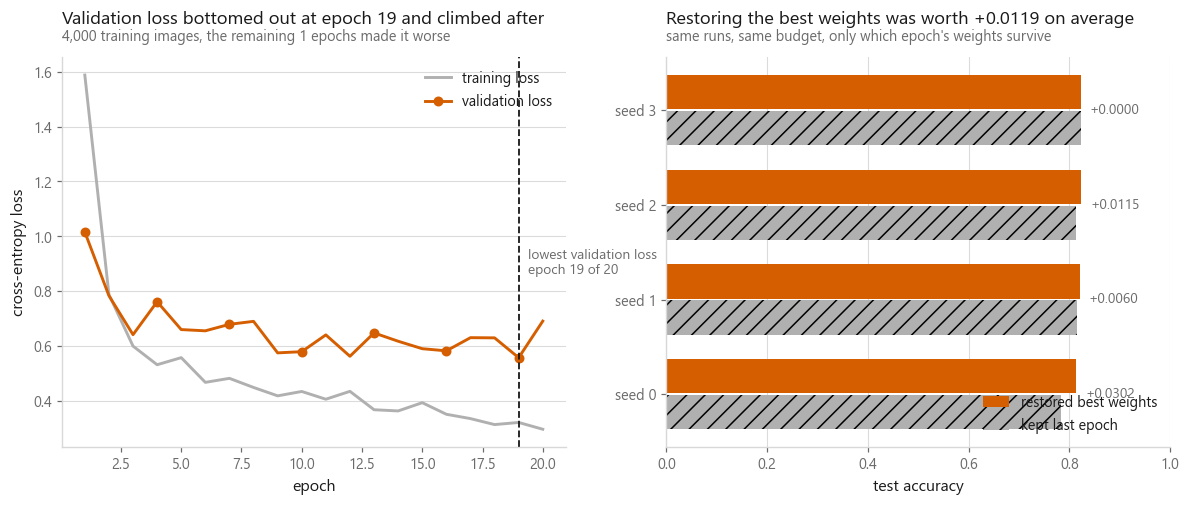

In [10]:
tracked = train_once(build_net(seed=SEED), seed=SEED, track_test=True)
epochs_axis = range(1, EPOCHS + 1)
chosen = tracked["best_epoch"]
peak_test_epoch = int(np.argmax(tracked["history"]["test_acc"])) + 1

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.6))

axes[0].plot(epochs_axis, tracked["history"]["train_loss"], color=style.NEUTRAL,
             label="training loss")
axes[0].plot(epochs_axis, tracked["history"]["val_loss"], color=style.HIGHLIGHT,
             marker=style.MARKERS[0], markevery=3, label="validation loss")
axes[0].axvline(chosen, color=style.INK, ls="--", lw=1.2)
axes[0].annotate(f"lowest validation loss\nepoch {chosen} of {EPOCHS}",
                 xy=(chosen, max(tracked["history"]["val_loss"]) * 0.85),
                 xytext=(6, 0), textcoords="offset points", fontsize=9, color=style.MUTED)
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("cross-entropy loss")
axes[0].legend(loc="upper right")
style.title(axes[0], f"Validation loss bottomed out at epoch {chosen} and climbed after",
            f"{N_TRAIN:,} training images, the remaining {EPOCHS - chosen} epochs made it worse")

positions = np.arange(len(restoration))
axes[1].barh(positions + 0.19, restoration["test acc, best weights"], height=0.36,
             color=style.HIGHLIGHT, label="restored best weights")
axes[1].barh(positions - 0.19, restoration["test acc, last weights"], height=0.36,
             color=style.NEUTRAL, hatch="//", label="kept last epoch")
for i, difference in enumerate(restoration["difference"]):
    axes[1].annotate(f"{difference:+.4f}",
                     xy=(restoration["test acc, best weights"].iloc[i], positions[i]),
                     xytext=(6, 0), textcoords="offset points", va="center",
                     fontsize=9, color=style.MUTED)
axes[1].set_yticks(positions, [f"seed {s}" for s in restoration["seed"]])
axes[1].set_xlim(0, 1.0)
axes[1].set_xlabel("test accuracy")
axes[1].grid(axis="y", visible=False)
axes[1].grid(axis="x", visible=True)
axes[1].legend(loc="lower right")
style.title(axes[1], f"Restoring the best weights was worth {mean_gain:+.4f} on average",
            "same runs, same budget, only which epoch's weights survive")

style.save(fig, FIG / "fig-02-best-weights.png")

### The reason the validation set has to be separate

The run above also recorded test accuracy every epoch, which is something you must
never do in real work and which is useful exactly once, here, to show what it buys
you if you cheat.

Two ways to pick the epoch to report. Pick it by validation loss, which is honest.
Or pick the epoch where the test accuracy happened to peak, which is what "I tried
a few epoch counts and reported the best" quietly amounts to.

In [11]:
honest = tracked["history"]["test_acc"][chosen - 1]
flattering = max(tracked["history"]["test_acc"])
print(f"test accuracy at the epoch validation chose (epoch {chosen}) : {honest:.4f}")
print(f"best test accuracy at any epoch (epoch {peak_test_epoch})            : {flattering:.4f}")
print(f"optimism bought by peeking at the test set                : {flattering - honest:+.4f}")
print("\nthat gap is not a modelling gain. It is the amount you would be overstating.")

test accuracy at the epoch validation chose (epoch 19) : 0.8132
best test accuracy at any epoch (epoch 16)            : 0.8230
optimism bought by peeking at the test set                : +0.0098

that gap is not a modelling gain. It is the amount you would be overstating.


### Piece six: learning-rate scheduling

One learning rate has to be both large enough to move early and small enough to
settle late, and no single number is both. A schedule lets it be large first and
small later.

A constant rate against three schedules, same budget, same seed, same starting
rate. `step` cuts the rate on a fixed calendar, `cosine` follows the formula from
section 2, and `plateau` waits until the validation loss stops improving before it
moves.

In [12]:
# "none" is already in hand: runs[SEED] used the default constant rate with the
# same seed, epochs and learning rate, so refitting it would only burn time.
schedule_runs = {"none": runs[SEED]}
for name in ["step", "cosine", "plateau"]:
    schedule_runs[name] = train_once(build_net(seed=SEED), seed=SEED, schedule=name)

rows = []
for name, run in schedule_runs.items():
    probe = build_net(seed=SEED)
    probe.load_state_dict(run["best_state"])
    rows.append({"schedule": name,
                 "best val loss": run["best_val_loss"],
                 "best epoch": run["best_epoch"],
                 "final lr": run["history"]["lr"][-1],
                 "test acc, best weights": evaluate(probe, X_test, y_test, loss_fn)[1]})

schedule_table = pd.DataFrame(rows)
print(schedule_table.round(4).to_string(index=False))

schedule_winner = schedule_table.loc[schedule_table["test acc, best weights"].idxmax(), "schedule"]
schedule_gain = (schedule_table["test acc, best weights"].max()
                 - schedule_table.loc[schedule_table["schedule"] == "none",
                                      "test acc, best weights"].iloc[0])
print(f"\nbest schedule here: {schedule_winner}, worth {schedule_gain:+.4f} over a constant rate")
print(f"seed spread for comparison: {final_val.max() - final_val.min():.4f}")

schedule  best val loss  best epoch  final lr  test acc, best weights
    none         0.5569          19    0.1000                  0.8132
    step         0.4947          19    0.0090                  0.8294
  cosine         0.4891          19    0.0006                  0.8309
 plateau         0.4972          10    0.0062                  0.8214

best schedule here: cosine, worth +0.0177 over a constant rate
seed spread for comparison: 0.0480


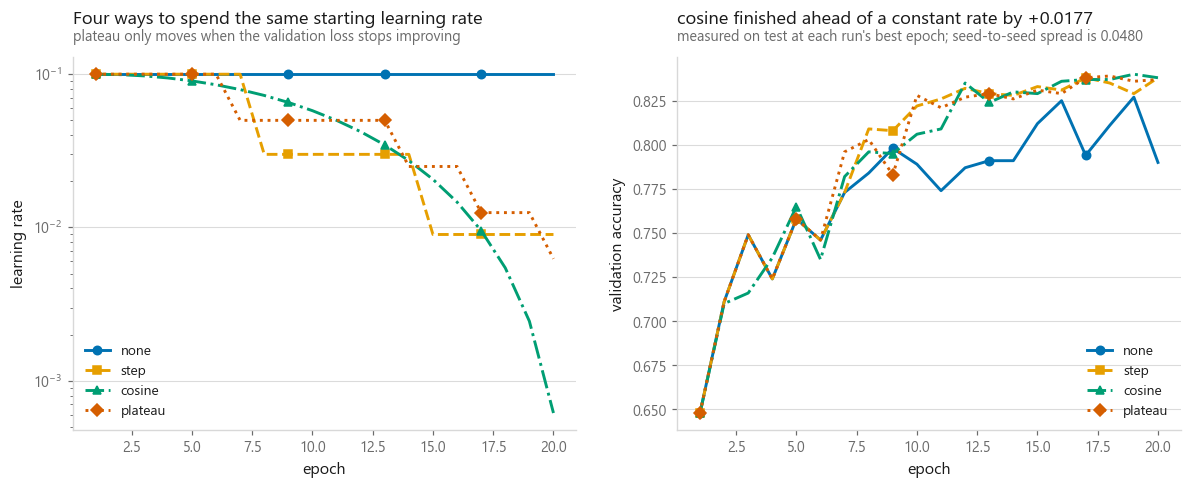

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.4))
for i, (name, run) in enumerate(schedule_runs.items()):
    axes[0].plot(epochs_axis, run["history"]["lr"], color=style.PALETTE[i],
                 ls=style.DASHES[i], marker=style.MARKERS[i], markevery=4, label=name)
    axes[1].plot(epochs_axis, run["history"]["val_acc"], color=style.PALETTE[i],
                 ls=style.DASHES[i], marker=style.MARKERS[i], markevery=4, label=name)

axes[0].set_xlabel("epoch")
axes[0].set_ylabel("learning rate")
axes[0].set_yscale("log")
axes[0].legend(loc="lower left", fontsize=9)
style.title(axes[0], "Four ways to spend the same starting learning rate",
            "plateau only moves when the validation loss stops improving")

axes[1].set_xlabel("epoch")
axes[1].set_ylabel("validation accuracy")
axes[1].legend(loc="lower right", fontsize=9)
headline = ("No schedule beat the constant rate here" if schedule_winner == "none"
            else f"{schedule_winner} finished ahead of a constant rate by {schedule_gain:+.4f}")
style.title(axes[1], headline,
            f"measured on test at each run's best epoch; seed-to-seed spread is "
            f"{final_val.max() - final_val.min():.4f}")

style.save(fig, FIG / "fig-03-schedules.png")

Whether that difference is real depends on how it compares to the seed spread
printed above it, and both numbers are on the chart so the comparison cannot be
avoided. A schedule is cheap and rarely harmful, which is a better reason to use
one than a single-run improvement.

### Piece seven: gradient clipping

Clipping is sold as the piece that does nothing at all until the day it does
everything. It costs one norm computation per step, and on the step where the
norm arrives an order of magnitude larger than usual it is supposed to be the
difference between a model and a tensor full of `nan`.

Both halves of that sentence are checkable, and neither of them came through this
notebook intact. How often a clip fires on an ordinary run is a question rather
than an assumption, so the first thing to do is look at the norms on a run that
never had trouble.

In [14]:
normal = train_once(build_net(seed=SEED), seed=SEED, epochs=5, lr=0.1, collect_norms=True)
norms = np.array(normal["grad_norms"])
CLIP = 1.0
print(f"gradient norms over {len(norms):,} steps at a sane learning rate")
print(f"  median {np.median(norms):.4f}   90th percentile {np.quantile(norms, 0.9):.4f}   "
      f"max {norms.max():.4f}")
print(f"  share of steps a clip at {CLIP} would touch: {(norms > CLIP).mean():.4f}")

gradient norms over 160 steps at a sane learning rate
  median 1.0596   90th percentile 1.9720   max 4.1656
  share of steps a clip at 1.0 would touch: 0.5938


The threshold I reached for out of habit sits below the median norm of a run that
trained perfectly well, and the printed share says it would rescale most of the
steps in that run. That is not a safety net lying dormant.

Think about what it does on those steps. The direction of the update survives and
its length is replaced by the threshold, so every step above the threshold is
taken at a smaller effective learning rate than the one in the optimiser, and
every step below it is taken at the declared rate. A clip set under the bulk of
the distribution is a second learning-rate dial, applied unevenly, that nobody
wrote down and nobody tuned.

The other half of the claim is the sweep below: push the learning rate until
training falls over, and see whether clipping is what catches it.

In [15]:
LR_SWEEP = [0.05, 0.2, 1.0, 3.0, 8.0, 20.0]
survival = []
for lr in LR_SWEEP:
    for clip in [None, CLIP]:
        run = train_once(build_net(seed=SEED), seed=SEED, epochs=4, lr=lr, clip=clip)
        losses = np.array(run["history"]["train_loss"])
        survival.append({"lr": lr, "clipping": "off" if clip is None else f"norm <= {CLIP}",
                         "final train loss": losses[-1],
                         "finite": bool(np.isfinite(losses).all()),
                         "best val acc": max(run["history"]["val_acc"])})

survival = pd.DataFrame(survival)
print(survival.round(4).to_string(index=False))

broken_off = int((~survival[survival["clipping"] == "off"]["finite"]).sum())
broken_on = int((~survival[survival["clipping"] != "off"]["finite"]).sum())
print(f"\nruns that produced a non-finite loss without clipping : {broken_off} of {len(LR_SWEEP)}")
print(f"runs that produced a non-finite loss with clipping    : {broken_on} of {len(LR_SWEEP)}")

# Nothing diverged, so the interesting column is what clipping cost rather than
# what it saved. Pair the rows by learning rate and look at the sign.
paired = survival.pivot(index="lr", columns="clipping", values="final train loss")
paired["clipping made the loss"] = np.where(
    paired[f"norm <= {CLIP}"] > paired["off"], "worse", "better")
print()
print(paired.round(4).to_string())
hurt = int((paired["clipping made the loss"] == "worse").sum())
print(f"\nlearning rates where clipping ended on a worse training loss: "
      f"{hurt} of {len(LR_SWEEP)}")
print(f"learning rates where it ended on a better one              : "
      f"{len(LR_SWEEP) - hurt} of {len(LR_SWEEP)}")

   lr    clipping  final train loss  finite  best val acc
 0.05         off            0.5843    True         0.747
 0.05 norm <= 1.0            0.6670    True         0.717
 0.20         off            0.6901    True         0.702
 0.20 norm <= 1.0            0.5842    True         0.753
 1.00         off            2.3128    True         0.121
 1.00 norm <= 1.0            2.1089    True         0.360
 3.00         off            2.3478    True         0.121
 3.00 norm <= 1.0            2.3500    True         0.121
 8.00         off            2.5498    True         0.121
 8.00 norm <= 1.0            2.5645    True         0.121
20.00         off           22.2093    True         0.099
20.00 norm <= 1.0           31.1005    True         0.099

runs that produced a non-finite loss without clipping : 0 of 6
runs that produced a non-finite loss with clipping    : 0 of 6

clipping  norm <= 1.0      off clipping made the loss
lr                                                   
0.05      

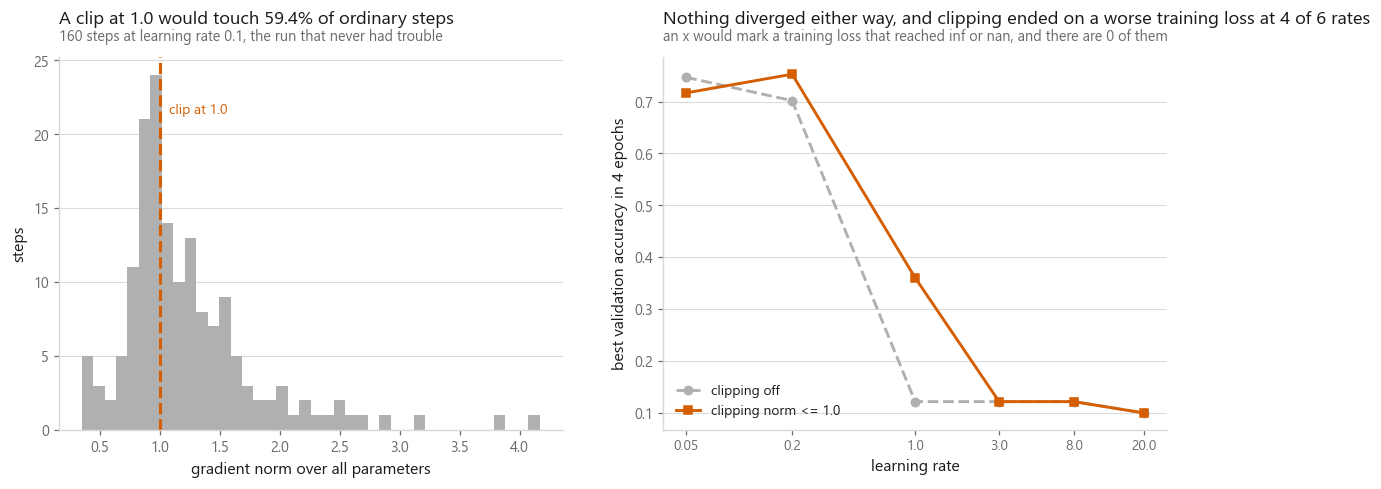

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.4))

axes[0].hist(norms, bins=40, color=style.NEUTRAL)
axes[0].axvline(CLIP, color=style.HIGHLIGHT, lw=2.0, ls="--")
axes[0].annotate(f"clip at {CLIP}", xy=(CLIP, axes[0].get_ylim()[1] * 0.85),
                 xytext=(6, 0), textcoords="offset points", fontsize=9, color=style.HIGHLIGHT)
axes[0].set_xlabel("gradient norm over all parameters")
axes[0].set_ylabel("steps")
style.title(axes[0], f"A clip at {CLIP} would touch {(norms > CLIP).mean():.1%} of ordinary steps",
            f"{len(norms):,} steps at learning rate 0.1, the run that never had trouble")

for i, label in enumerate(["off", f"norm <= {CLIP}"]):
    block = survival[survival["clipping"] == label]
    axes[1].plot(block["lr"], block["best val acc"], color=[style.NEUTRAL, style.HIGHLIGHT][i],
                 marker=style.MARKERS[i], ls=["--", "-"][i], label=f"clipping {label}")
    dead = block[~block["finite"]]
    if len(dead):
        axes[1].scatter(dead["lr"], dead["best val acc"], s=110, marker="x",
                        color=style.INK, zorder=5,
                        label="loss went non-finite" if i == 0 else None)
axes[1].set_xscale("log")
axes[1].set_xticks(LR_SWEEP, [str(v) for v in LR_SWEEP], fontsize=9)
axes[1].minorticks_off()
axes[1].set_xlabel("learning rate")
axes[1].set_ylabel("best validation accuracy in 4 epochs")
axes[1].legend(loc="lower left", fontsize=9)
rescued = broken_off - broken_on
clip_headline = (f"Clipping kept {rescued} more runs alive across the sweep" if rescued
                 else f"Nothing diverged either way, and clipping ended on a worse "
                      f"training loss at {hurt} of {len(LR_SWEEP)} rates")
style.title(axes[1], clip_headline,
            f"an x would mark a training loss that reached inf or nan, and there are "
            f"{broken_off + broken_on} of them")

style.save(fig, FIG / "fig-04-clipping.png")

The sweep was built to produce a divergence and it did not produce one. The two
printed counts are the result: no run reached a non-finite loss, with clipping or
without it, so the rescue clipping is famous for had nothing to rescue here.
Cross-entropy on a small fully connected network does not explode when the
learning rate is too large. It settles into a flat, useless region and keeps
reporting a perfectly finite number, which the accuracies at the right of the
chart describe better than the losses do.

What the table does show is a cost. Clipping ended on a worse training loss at
most of the learning rates tried, including the largest one in the sweep, and at
the smallest one it also finished with lower validation accuracy. It helped at two
of the rates. That is what a second, undeclared learning-rate dial looks like: not
a disaster, and not a free insurance policy either, because the sign of its effect
is not the same at every setting.

So the honest version of the advice is narrower than the slogan. Clipping is
worth having where gradients genuinely spike, which is recurrent networks, long
sequences, reinforcement learning and mixed precision, and the threshold has to
be chosen above the norms you measured rather than copied from a config file. On
this network at this threshold it was neither inert nor a rescue.

### Piece eight: checkpointing

Two different jobs get called checkpointing and they need different contents.

**Keeping the best model** needs only the weights. **Resuming a crashed run** needs
the optimiser state as well, because momentum buffers and Adam's moment estimates
are state that took as long to build as the weights did, and restarting without
them is a visible jolt in the loss curve.

Save both, plus enough metadata to know what you are looking at six months later.

In [17]:
workspace = tempfile.TemporaryDirectory()          # a real project uses a real directory
CHECKPOINT = pathlib.Path(workspace.name) / "best.pt"

reference = schedule_runs["cosine"]        # already trained, no need to burn another run
torch.save({
    "model": reference["best_state"],
    "optimiser": reference["optimiser_state"],
    "epoch": reference["best_epoch"],
    "val_loss": reference["best_val_loss"],
    "seed": SEED,
    "classes": CLASSES,
}, CHECKPOINT)

# weights_only=True refuses to unpickle arbitrary objects. It has been the default
# since torch 2.6 and it is worth writing out, because a checkpoint is a file you
# might not have made.
restored = torch.load(CHECKPOINT, weights_only=True)
fresh = build_net(seed=999)                        # deliberately different initial weights
fresh.load_state_dict(restored["model"])

with torch.no_grad():
    original = build_net(seed=SEED)
    original.load_state_dict(reference["best_state"])
    original.eval(), fresh.eval()
    gap = (original(X_test[:2000]) - fresh(X_test[:2000])).abs().max().item()

print(f"checkpoint written: {CHECKPOINT.stat().st_size / 1e6:.2f} MB")
print(f"it records epoch {restored['epoch']} with validation loss {restored['val_loss']:.4f}")
print(f"largest logit difference after reloading into a fresh network: {gap:.3e}")

checkpoint written: 0.88 MB
it records epoch 19 with validation loss 0.4891
largest logit difference after reloading into a fresh network: 0.000e+00


## 4. In practice: the whole thing, once

Every piece above, in one function, with nothing in it that has not been justified.
This is the part to copy.

In [18]:
def fit(model, train_data, val_data, *, epochs=30, lr=0.1, batch_size=128,
        weight_decay=0.0, schedule="cosine", clip=1.0, patience=5, seed=0,
        checkpoint=None, device=None, verbose=True):
    """Train `model`, keep the best weights, and hand them back.

    train_data and val_data are (X, y) tensor pairs. Returns (model, history) with
    the model already holding the weights from the lowest validation loss.
    """
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    seed_everything(seed)

    model = model.to(device)
    X_fit, y_fit = train_data[0].to(device), train_data[1].to(device)
    X_check, y_check = val_data[0].to(device), val_data[1].to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimiser = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9,
                                weight_decay=weight_decay)
    loader = DataLoader(TensorDataset(X_fit, y_fit), batch_size=batch_size, shuffle=True,
                        generator=torch.Generator().manual_seed(seed))

    scheduler = (torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=epochs)
                 if schedule == "cosine" else None)

    history = {k: [] for k in ["train_loss", "val_loss", "val_acc", "lr"]}
    best_loss, best_state, best_epoch, waited = math.inf, None, 0, 0

    for epoch in range(1, epochs + 1):
        model.train()
        running = Average()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)          # assign the result, never call .to() bare
            optimiser.zero_grad(set_to_none=True)
            loss = loss_fn(model(xb), yb)
            loss.backward()
            if clip:
                nn.utils.clip_grad_norm_(model.parameters(), clip)
            optimiser.step()
            running.add(loss.item(), len(yb))              # weighted by rows, not by batches

        val_loss, val_accuracy = evaluate(model, X_check, y_check, loss_fn)
        history["train_loss"].append(running.value)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_accuracy)
        history["lr"].append(optimiser.param_groups[0]["lr"])

        if val_loss < best_loss - 1e-6:                    # a tolerance, so noise is not "improvement"
            best_loss, best_epoch, waited = val_loss, epoch, 0
            best_state = copy.deepcopy(model.state_dict())
            if checkpoint is not None:
                torch.save({"model": best_state, "optimiser": optimiser.state_dict(),
                            "epoch": epoch, "val_loss": val_loss, "seed": seed}, checkpoint)
        else:
            waited += 1

        if verbose and (epoch == 1 or epoch % 5 == 0):
            print(f"  epoch {epoch:>3}  train {running.value:.4f}  val {val_loss:.4f}  "
                  f"acc {val_accuracy:.4f}  lr {history['lr'][-1]:.5f}")

        if waited >= patience:
            if verbose:
                print(f"  stopped at epoch {epoch}: {patience} epochs without improvement")
            break

        if scheduler is not None:
            scheduler.step()

    if best_state is not None:
        model.load_state_dict(best_state)                  # the run ends on its best weights
    history["best_epoch"] = best_epoch
    history["best_val_loss"] = best_loss
    return model, history

## 5. When it wins, when it loses

The complete loop against the loop from section 1, same architecture, same seed,
same data, same maximum number of epochs. The naive version gets the same training
rows, so it is not being punished for the validation split; the only differences
are the pieces.

In [19]:
def train_naive(model, epochs=40, lr=0.1, batch_size=BATCH, seed=SEED):
    """Section 1's loop, unchanged, with a per-epoch record bolted on for the chart."""
    seed_everything(seed)
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimiser = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True,
                        generator=torch.Generator().manual_seed(seed))

    curve = []
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            optimiser.zero_grad()
            loss_fn(model(xb), yb).backward()
            optimiser.step()
        curve.append(evaluate(model, X_val, y_val, loss_fn)[1])
    return model, curve


MAX_EPOCHS = 40

started = time.perf_counter()
naive_model, naive_curve = train_naive(build_net(seed=SEED), epochs=MAX_EPOCHS)
naive_seconds = time.perf_counter() - started
naive_test = evaluate(naive_model, X_test, y_test, loss_fn)[1]

print("complete loop:")
started = time.perf_counter()
full_model, full_history = fit(build_net(seed=SEED), (X_train, y_train), (X_val, y_val),
                               epochs=MAX_EPOCHS, lr=0.1, schedule="cosine", clip=CLIP,
                               patience=6, seed=SEED, checkpoint=CHECKPOINT)
full_seconds = time.perf_counter() - started
full_test = evaluate(full_model, X_test, y_test, loss_fn)[1]

comparison = pd.DataFrame([
    {"loop": "section 1, as written", "epochs run": MAX_EPOCHS,
     "test accuracy": naive_test, "seconds": naive_seconds},
    {"loop": "complete", "epochs run": len(full_history["val_acc"]),
     "test accuracy": full_test, "seconds": full_seconds},
])
print()
print(comparison.round(4).to_string(index=False))
print(f"\ndifference in test accuracy : {full_test - naive_test:+.4f}")
print(f"seed spread measured earlier: {final_val.max() - final_val.min():.4f}")
print(f"epochs saved by early stopping: {MAX_EPOCHS - len(full_history['val_acc'])}")

complete loop:
  epoch   1  train 1.5572  val 1.2744  acc 0.5600  lr 0.10000


  epoch   5  train 0.5189  val 0.6449  acc 0.7690  lr 0.09755


  epoch  10  train 0.3905  val 0.5255  acc 0.8140  lr 0.08802


  epoch  15  train 0.3482  val 0.6177  acc 0.7900  lr 0.07270


  epoch  20  train 0.2498  val 0.5108  acc 0.8440  lr 0.05392


  epoch  25  train 0.1631  val 0.5825  acc 0.8280  lr 0.03455


  stopped at epoch 28: 6 epochs without improvement

                 loop  epochs run  test accuracy  seconds
section 1, as written          40         0.8020   2.7196
             complete          28         0.8227   2.5139

difference in test accuracy : +0.0207
seed spread measured earlier: 0.0480
epochs saved by early stopping: 12


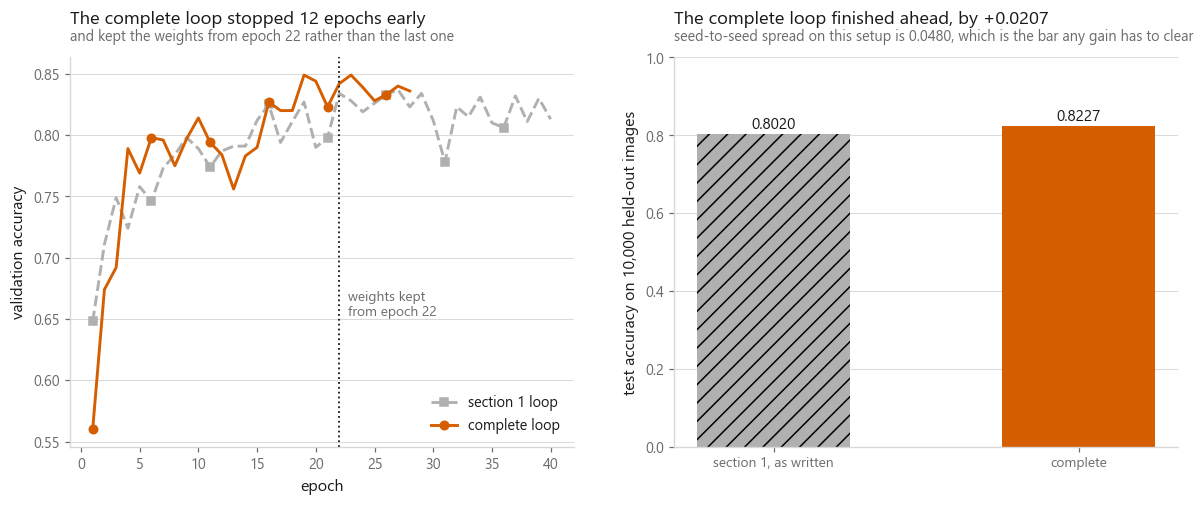

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.6))

axes[0].plot(range(1, len(naive_curve) + 1), naive_curve, color=style.NEUTRAL,
             ls="--", marker=style.MARKERS[1], markevery=5, label="section 1 loop")
axes[0].plot(range(1, len(full_history["val_acc"]) + 1), full_history["val_acc"],
             color=style.HIGHLIGHT, marker=style.MARKERS[0], markevery=5, label="complete loop")
axes[0].axvline(full_history["best_epoch"], color=style.INK, ls=":", lw=1.2)
axes[0].annotate(f"weights kept\nfrom epoch {full_history['best_epoch']}",
                 xy=(full_history["best_epoch"], min(naive_curve)), xytext=(6, 4),
                 textcoords="offset points", fontsize=9, color=style.MUTED)
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("validation accuracy")
axes[0].legend(loc="lower right")
style.title(axes[0], f"The complete loop stopped {MAX_EPOCHS - len(full_history['val_acc'])} epochs early",
            f"and kept the weights from epoch {full_history['best_epoch']} rather than the last one")

positions = [0, 1]
axes[1].bar(positions, comparison["test accuracy"], width=0.5,
            color=[style.NEUTRAL, style.HIGHLIGHT], hatch=["//", ""])
for x, value in zip(positions, comparison["test accuracy"]):
    axes[1].annotate(f"{value:.4f}", xy=(x, value), xytext=(0, 4),
                     textcoords="offset points", ha="center", fontsize=10, color=style.INK)
axes[1].set_xticks(positions, comparison["loop"], fontsize=9)
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel(f"test accuracy on {len(X_test):,} held-out images")
verdict = ("The complete loop finished ahead" if full_test > naive_test
           else "The complete loop did not finish ahead")
style.title(axes[1], f"{verdict}, by {full_test - naive_test:+.4f}",
            f"seed-to-seed spread on this setup is {final_val.max() - final_val.min():.4f}, "
            "which is the bar any gain has to clear")

style.save(fig, FIG / "fig-05-complete-loop.png")

Read the right-hand panel against its own subtitle before deciding the loop is
worth it. On a small, well-behaved problem like this one, most of the machinery is
insurance rather than improvement, and insurance does not show up in a single
number on a good day.

What it does buy, and what no accuracy comparison can show, is that the number
above is one you can defend. It was chosen by a validation set the test data never
touched, at an epoch picked by a rule rather than by taste, from weights that were
saved rather than reconstructed, in a run you can reproduce by passing the same
seed.

### What to leave out

Not every piece pays everywhere, and adding all of them by reflex is its own kind
of sloppiness.

Gradient clipping at the threshold used here is the piece that failed its own
audit. The histogram put the median gradient norm of a healthy run above the
threshold, and the printed share says the clip would fire on most of that run's
steps. A threshold below the typical norm is not a safety net that never triggers.
It is a learning-rate change applied to the large-gradient steps and withheld from
the small ones, which is a different optimiser from the one in the code above it.

Keep clipping, and pick the number rather than inheriting it. Run a few hundred
steps, look at the distribution of norms, and put the threshold above the bulk of
it so the clip does nothing on ordinary steps and is still there for the outlier.
The default of 1.0 is a value from papers about recurrent networks, and this is
not one.

Learning-rate scheduling can be dropped when a run is short enough that the rate
never needed to change. Compare the schedule table against the seed spread before
claiming it earned its place.

Early stopping should not be dropped. It is the one piece in this notebook that
costs negative time, and the measurement in section 3 says what keeping the last
epoch's weights costs instead.

Checkpointing is pointless for a run that takes forty seconds and essential for one
that takes forty hours. The threshold is however long you are willing to lose.

## Cheat sheet

| | |
|---|---|
| **Device** | Select once at the top. `model.to(device)` is in place, `tensor.to(device)` is not. Assign the result |
| **Splits** | Train, validation, test. Anything you make a decision with is a validation set, whatever you called it |
| **Metrics** | Accumulate weighted by rows. Dividing by `len(loader)` is dividing by batches, and it is wrong whenever the last batch is short |
| **Eval mode** | `model.eval()` and `torch.no_grad()` belong inside the evaluation function, not at the call site |
| **Early stopping** | Patience on validation loss, with a tolerance so noise does not count as improvement |
| **Best weights** | `copy.deepcopy(model.state_dict())`, and load it back before you return. A reference is not a copy |
| **Scheduling** | Cosine annealing when in doubt. It has one dial and it is the epoch count you already chose |
| **Clipping** | `nn.utils.clip_grad_norm_` by norm, not by value. Inert only when the threshold sits above the norms you actually see. The one used here sat below the median norm of a healthy run and fired on most of its steps, which makes it a learning-rate change rather than a guard rail. Measure the norms, then pick the number |
| **Checkpoints** | Weights for keeping the best, weights plus optimiser state for resuming. `weights_only=True` when loading |
| **Seeds** | Set python, numpy and torch, and pass a generator to the DataLoader. Then measure the spread across seeds before believing any improvement |
| **Next** | [Convolution and pooling](../../08-computer-vision/01-convolution-and-pooling/), where the same loop trains a very different network |

## What to remember

1. Averaging a metric over batches instead of over rows is wrong whenever the last
   batch is short, and the error is largest exactly when the evaluation set is
   grouped rather than shuffled.
2. Early stopping and best-weight restoration are two things. Doing the first
   without the second keeps the weights from your worst recent epoch.
3. `copy.deepcopy(model.state_dict())` or the saved weights keep training with the
   model.
4. Measure the seed-to-seed spread first. It is the bar every later comparison in
   the notebook has to clear, and most single-run improvements do not clear it.
5. Selecting an epoch by test accuracy is not a modelling result, it is optimism,
   and section 3 puts a number on how much.
6. Gradient clipping was not inert here. At the threshold everyone copies it fired
   on most steps of a healthy run, which makes it an unannounced learning-rate
   change, and the learning-rate sweep it was supposed to rescue never diverged
   for it to rescue. Set the threshold from measured norms, and expect nothing
   from it on a small fully connected network.
7. A checkpoint for keeping the best model needs weights. A checkpoint for
   resuming needs the optimiser state too.
8. Put `model.eval()` and `torch.no_grad()` inside the evaluation function so they
   cannot be forgotten at the call site.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [08-01 Convolution and pooling](../../08-computer-vision/01-convolution-and-pooling/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#DeepLearning` `#PyTorch` `#TrainingLoop` `#EarlyStopping` `#Checkpointing`
`#Reproducibility` `#MachineLearning` `#Python` `#MLTutorial` `#AI`